# AQI Predictor — SHAP Interpretability Analysis
**Project:** End-to-end serverless AQI prediction system 
**City:** Karachi, Pakistan 
**Model:** XGBoost (winner — CV R²=0.876) 
**Feature store:** MongoDB Atlas 



**Contents:**
1. Setup and model loading
2. SHAP value computation
3. Global feature importance
4. SHAP summary (beeswarm) plot
5. Top feature dependency plots
6. Local explanation — single prediction waterfall
7. Time-of-day SHAP analysis
8. Key findings

In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('')))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import gridfs
from pymongo import MongoClient
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

print('Libraries loaded.')

Libraries loaded.


## 1. Load Model and Feature Data

In [2]:
MONGO_URI = os.getenv('MONGO_URI')
DB_NAME   = os.getenv('MONGO_DB_NAME', 'aqi_predictor')

client = MongoClient(MONGO_URI)
db     = client[DB_NAME]
fs     = gridfs.GridFS(db)

# Load best model
model_doc = db['models'].find_one({'is_best': True})
if not model_doc:
    raise ValueError('No best model found. Run training pipeline first.')

artifact = pickle.loads(fs.get(model_doc['gridfs_id']).read())
model        = artifact['model']
scaler       = artifact['scaler']
feature_cols = artifact['feature_cols']

model_type = type(model).__name__
print(f'Model type   : {model_type}')
print(f'Model metrics: {model_doc["metrics"]}')
print(f'Feature count: {len(feature_cols)}')
print(f'Features     : {feature_cols}')

Model type   : XGBRegressor
Model metrics: {'rmse': 8.6391, 'mae': 2.2143, 'r2': 0.7365, 'rmse_cv': 6.0627, 'mae_cv': 2.8367, 'r2_cv': 0.8762}
Feature count: 36
Features     : ['pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2', 'log_pm2_5', 'log_pm10', 'log_no2', 'log_co', 'log_so2', 'temperature', 'humidity', 'pressure', 'wind_speed', 'pm2_5_x_wind', 'pm10_x_wind', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'peak_traffic_hour', 'aqi_momentum_3h', 'aqi_momentum_6h', 'aqi_std_6h', 'aqi_lag_1h', 'aqi_lag_2h', 'aqi_lag_3h', 'aqi_lag_6h', 'aqi_lag_12h', 'aqi_lag_24h', 'aqi_lag_48h', 'aqi_rolling_3h', 'aqi_rolling_6h', 'aqi_rolling_12h', 'aqi_rolling_24h']


In [3]:
# Load features from MongoDB and rebuild the same feature matrix as training
records = list(db['aqi_features'].find({}, {'_id': 0}))
df = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# --- same cleaning as training_pipeline ---
weather_cols = [c for c in ['temperature','humidity','pressure','wind_speed'] if c in df.columns]
all_zero = (df[weather_cols] == 0).all(axis=1)
df.loc[all_zero, weather_cols] = np.nan
df[weather_cols] = df[weather_cols].ffill().bfill()
df = df[df['aqi'] > 0].reset_index(drop=True)

# --- same feature engineering as training_pipeline ---
for col in ['pm2_5','pm10','no2','co','so2']:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

df['pm2_5_x_wind']      = df['pm2_5'] / (df['wind_speed'] + 1)
df['pm10_x_wind']       = df['pm10']  / (df['wind_speed'] + 1)
df['aqi_momentum_3h']   = (df['aqi'] - df['aqi_lag_3h']) / 3.0
df['aqi_momentum_6h']   = (df['aqi'] - df['aqi_lag_6h']) / 6.0
df['aqi_lag_48h']       = df['aqi'].shift(48)
df['peak_traffic_hour'] = df['hour'].between(15, 20).astype(int)
df['aqi_std_6h']        = df['aqi'].shift(1).rolling(6, min_periods=2).std().round(3).fillna(0)
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['target'] = df['aqi'].shift(-1)

df = df.dropna(subset=['target'] + feature_cols).reset_index(drop=True)
X = df[feature_cols].values.astype(float)
y = df['target'].values.astype(float)

if scaler is not None:
    X_input = scaler.transform(X)
else:
    X_input = X

print(f'Feature matrix: {X_input.shape}')
print(f'Records: {len(df)}')

Feature matrix: (2416, 36)
Records: 2416


## 2. Compute SHAP Values

In [4]:
# Use a background sample for efficiency (500 rows is enough)
np.random.seed(42)
bg_idx  = np.random.choice(len(X_input), min(500, len(X_input)), replace=False)
X_bg    = X_input[bg_idx]

# Use last 500 rows as explanation set (most recent data = most relevant)
X_explain = X_input[-500:]
df_explain = df.iloc[-500:].reset_index(drop=True)

model_type_name = type(model).__name__
print(f'Computing SHAP values for {model_type_name}...')

if model_type_name in ['XGBRegressor', 'RandomForestRegressor',
                        'ExtraTreesRegressor', 'GradientBoostingRegressor']:
    explainer   = shap.TreeExplainer(model, X_bg)
    shap_values = explainer.shap_values(X_explain)
elif model_type_name == 'Ridge':
    explainer   = shap.LinearExplainer(model, X_bg)
    shap_values = explainer.shap_values(X_explain)
elif model_type_name == 'StackingRegressor':
    # Use the best base learner for SHAP
    for name, est in model.estimators_:
        if type(est).__name__ in ['XGBRegressor','RandomForestRegressor',
                                   'ExtraTreesRegressor','GradientBoostingRegressor']:
            explainer   = shap.TreeExplainer(est, X_bg)
            shap_values = explainer.shap_values(X_explain)
            print(f'  Using {type(est).__name__} base learner for SHAP')
            break
else:
    explainer   = shap.KernelExplainer(model.predict, X_bg[:50])
    shap_values = explainer.shap_values(X_explain[:100])

print(f'SHAP values shape: {shap_values.shape}')
print('Done.')

Computing SHAP values for XGBRegressor...
SHAP values shape: (500, 36)
Done.


In [5]:
# Build a clean feature importance DataFrame
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('=== Top 15 Features by Mean |SHAP| ===')
print(shap_df.head(15).to_string(index=False))

=== Top 15 Features by Mean |SHAP| ===
        feature  importance
     aqi_lag_1h    9.505449
aqi_rolling_12h    1.172314
     aqi_lag_6h    1.017083
aqi_momentum_3h    0.987889
     aqi_lag_3h    0.890362
          pm2_5    0.728687
     aqi_lag_2h    0.647031
     aqi_std_6h    0.544930
 aqi_rolling_6h    0.441941
             o3    0.384194
           pm10    0.281066
aqi_momentum_6h    0.244229
       hour_cos    0.211827
    pm10_x_wind    0.198719
aqi_rolling_24h    0.165785


## 3. Global Feature Importance

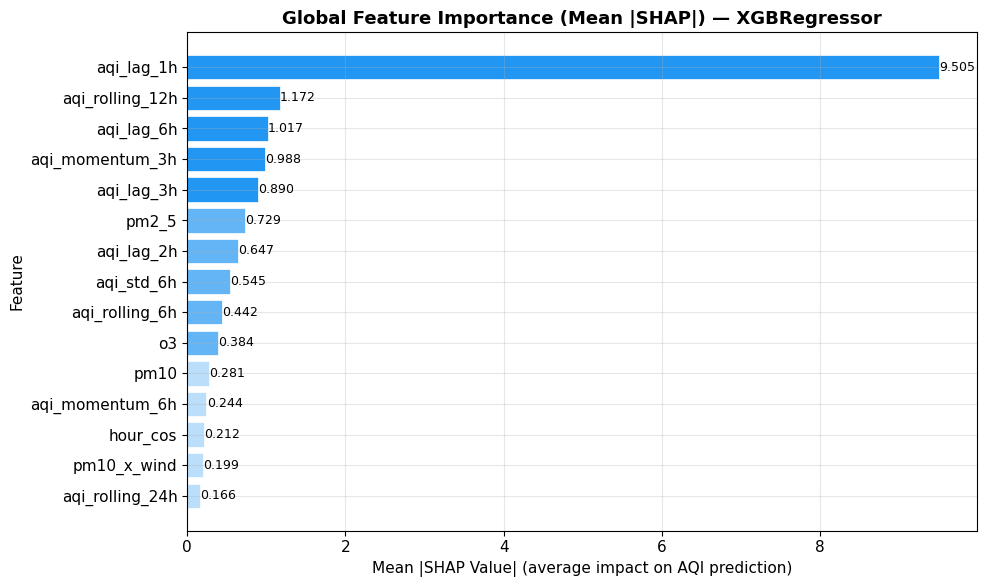

In [6]:
top_n = 15
top_df = shap_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if i < 5 else '#64B5F6' if i < 10 else '#BBDEFB'
          for i in range(len(top_df))]
bars = ax.barh(top_df['feature'][::-1], top_df['importance'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

# Value labels
for bar, val in zip(bars, top_df['importance'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title(f'Global Feature Importance (Mean |SHAP|) — {model_type_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value| (average impact on AQI prediction)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. SHAP Beeswarm (Summary) Plot

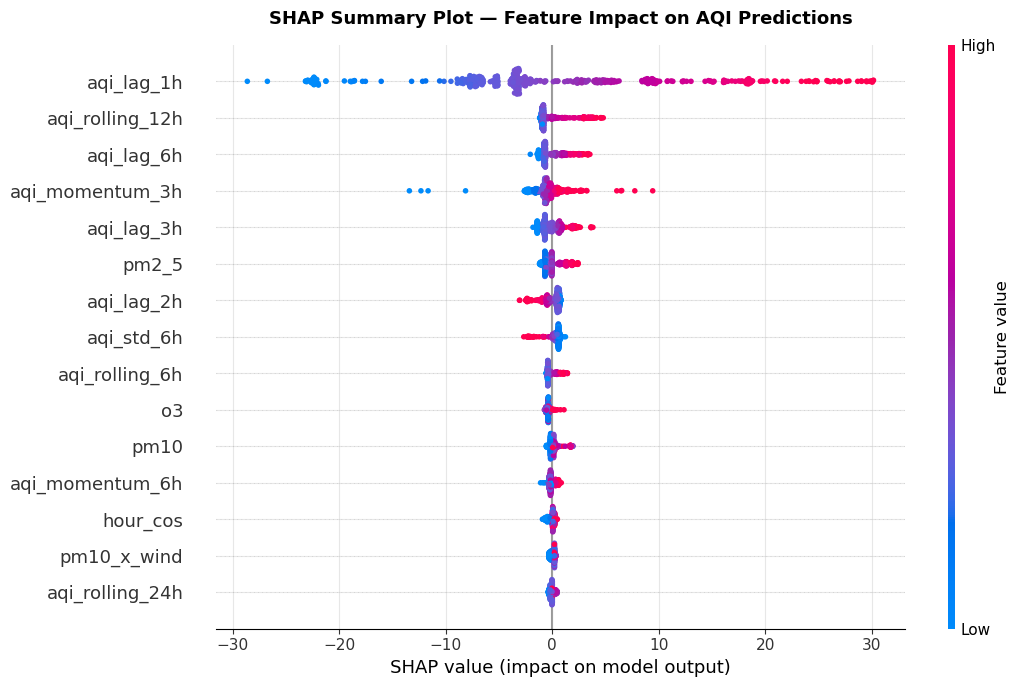

How to read this plot:
  Each dot = one prediction
  Red dot  = high value of that feature for that prediction
  Blue dot = low value of that feature for that prediction
  Right    = feature pushed AQI prediction higher
  Left     = feature pushed AQI prediction lower


In [7]:
# Red = high feature value, Blue = low feature value
# Right of center = pushed AQI prediction UP
# Left of center  = pushed AQI prediction DOWN

top_indices = shap_df.head(15).index.tolist()
top_feature_names = shap_df.head(15)['feature'].tolist()

# Get top feature indices in original feature_cols order
top_col_indices = [feature_cols.index(f) for f in top_feature_names]

fig, ax = plt.subplots(figsize=(11, 7))
shap.summary_plot(
    shap_values[:, top_col_indices],
    X_explain[:, top_col_indices],
    feature_names=top_feature_names,
    show=False,
    plot_size=None,
    max_display=15
)
plt.title('SHAP Summary Plot — Feature Impact on AQI Predictions',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

print('How to read this plot:')
print('  Each dot = one prediction')
print('  Red dot  = high value of that feature for that prediction')
print('  Blue dot = low value of that feature for that prediction')
print('  Right    = feature pushed AQI prediction higher')
print('  Left     = feature pushed AQI prediction lower')

## 5. Dependency Plots — Top 4 Features

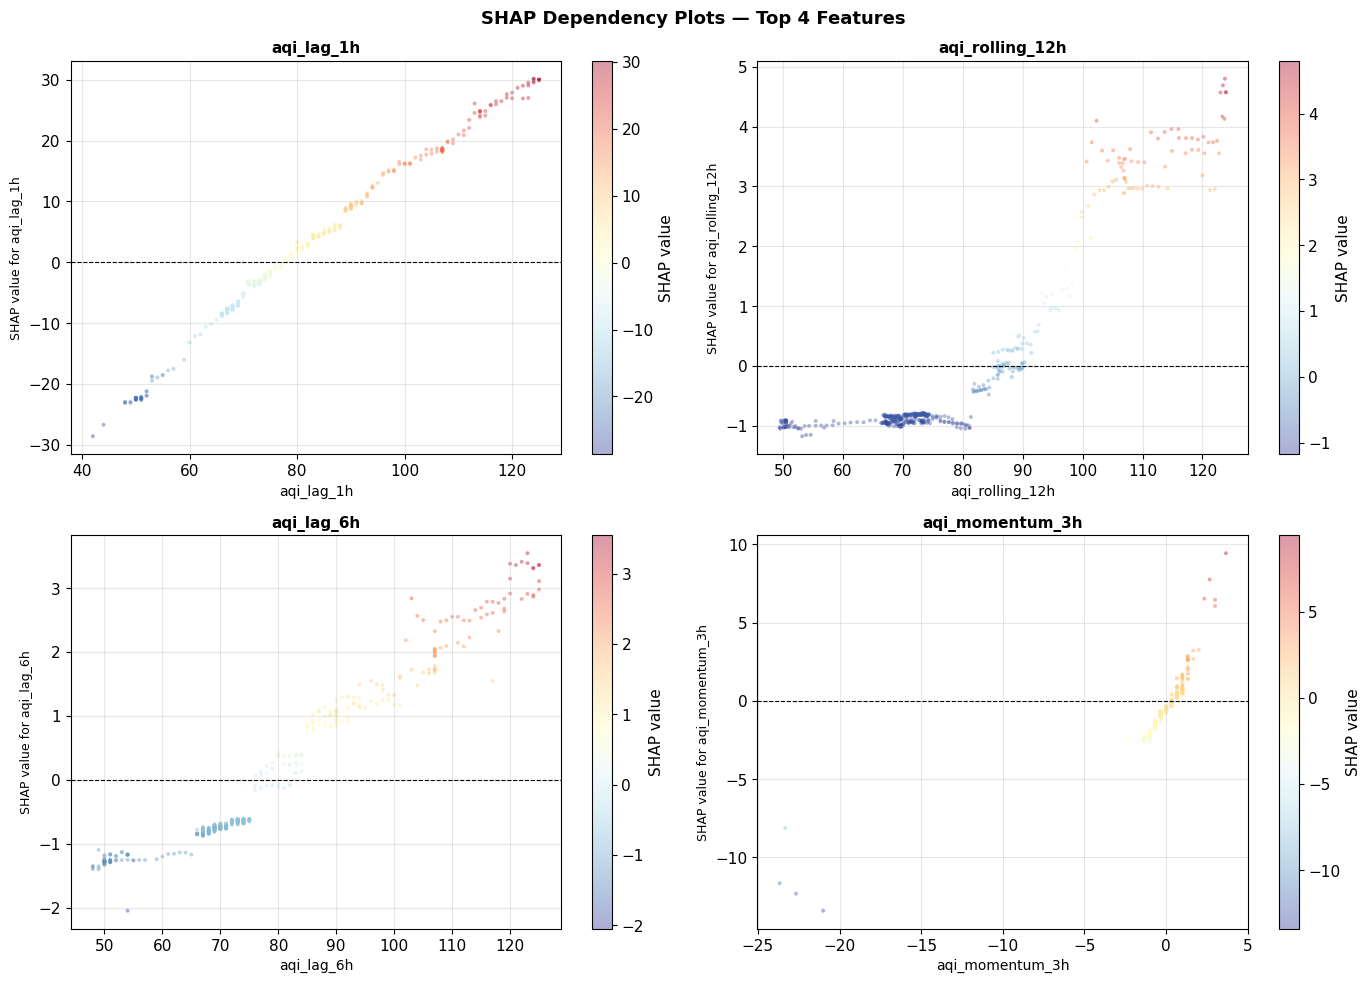

In [8]:
# Dependency plot: shows how SHAP value for a feature changes with its value
# Coloured by the most correlated interacting feature

top4 = shap_df.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependency Plots — Top 4 Features', fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flatten(), top4):
    feat_idx = feature_cols.index(feat)
    feat_vals  = X_explain[:, feat_idx]
    feat_shaps = shap_values[:, feat_idx]

    sc = ax.scatter(feat_vals, feat_shaps,
                    c=feat_shaps, cmap='RdYlBu_r',
                    alpha=0.4, s=8, linewidths=0)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel(f'SHAP value for {feat}', fontsize=9)
    ax.set_title(f'{feat}', fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='SHAP value')

plt.tight_layout()
plt.savefig('shap_dependency_top4.png', dpi=120, bbox_inches='tight')
plt.show()

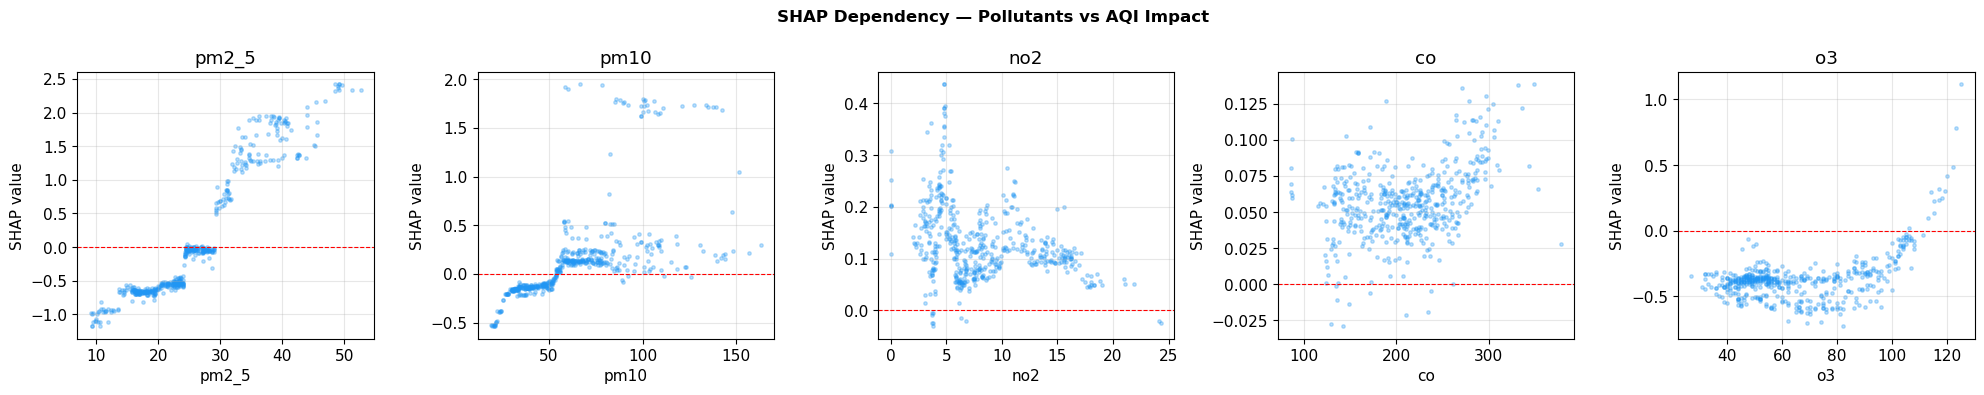

In [9]:
# Pollutant dependency plots — pm2_5, pm10, no2, co
pollutants = [f for f in ['pm2_5', 'pm10', 'no2', 'co', 'o3'] if f in feature_cols]

fig, axes = plt.subplots(1, len(pollutants), figsize=(4*len(pollutants), 4))
fig.suptitle('SHAP Dependency — Pollutants vs AQI Impact', fontsize=12, fontweight='bold')

for ax, feat in zip(axes.flatten(), pollutants):
    fidx = feature_cols.index(feat)
    ax.scatter(X_explain[:, fidx], shap_values[:, fidx],
               alpha=0.3, s=6, color='#2196F3')
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(feat)

plt.tight_layout()
plt.savefig('shap_pollutant_dependency.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Local Explanation — Single Prediction Waterfall

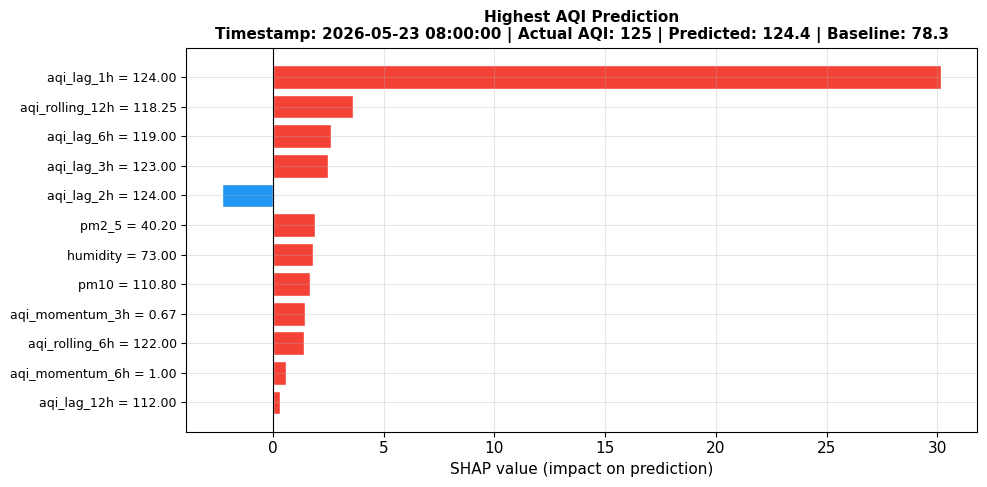

Highest AQI Prediction: predicted=124.4, actual=125


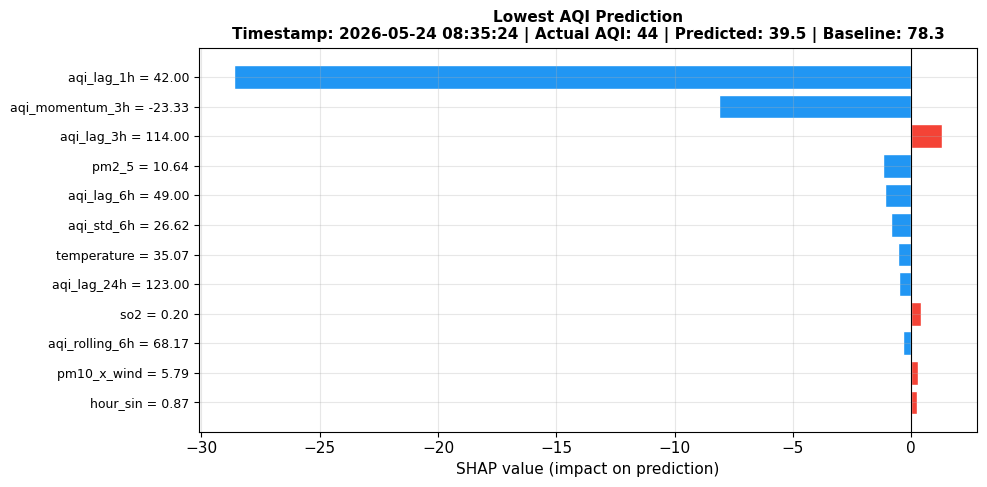

Lowest AQI Prediction: predicted=39.5, actual=44


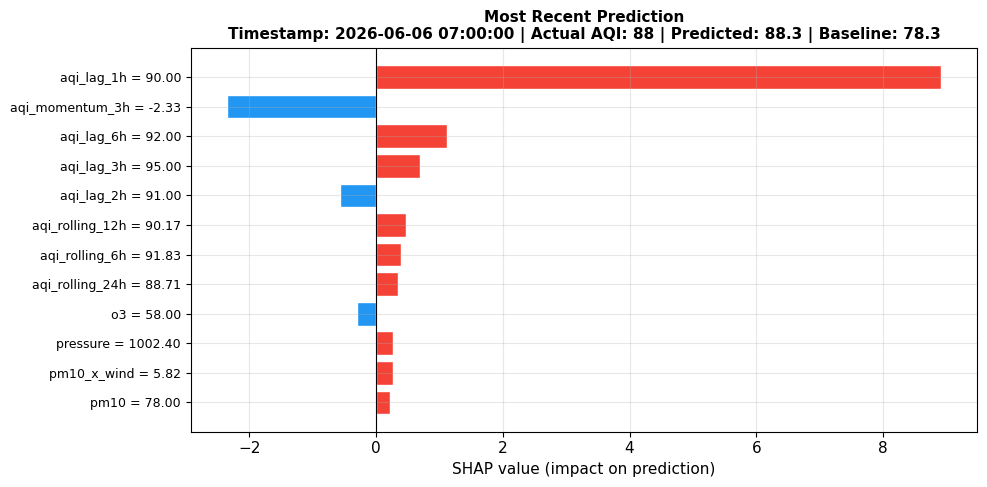

Most Recent Prediction: predicted=88.3, actual=88


In [10]:
# Pick 3 interesting cases to explain:
# 1. High AQI prediction
# 2. Low AQI prediction  
# 3. Most recent prediction

preds = model.predict(X_explain if scaler is None else X_explain)
high_idx   = np.argmax(preds)
low_idx    = np.argmin(preds)
recent_idx = len(preds) - 1

cases = [
    (high_idx,   'Highest AQI Prediction'),
    (low_idx,    'Lowest AQI Prediction'),
    (recent_idx, 'Most Recent Prediction'),
]

base_value = explainer.expected_value
if hasattr(base_value, '__len__'):
    base_value = base_value[0]

for idx, title in cases:
    sv   = shap_values[idx]
    pred = preds[idx]
    ts   = df_explain.iloc[idx]['timestamp'] if 'timestamp' in df_explain.columns else ''
    actual_aqi = df_explain.iloc[idx]['aqi'] if 'aqi' in df_explain.columns else '?'

    # Sort by absolute SHAP for waterfall
    order    = np.argsort(np.abs(sv))[::-1][:12]
    sv_top   = sv[order]
    feat_top = [feature_cols[i] for i in order]
    val_top  = [X_explain[idx, i] for i in order]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors  = ['#F44336' if v > 0 else '#2196F3' for v in sv_top]
    bars = ax.barh(range(len(sv_top)), sv_top[::-1],
                   color=colors[::-1], edgecolor='white')
    ax.set_yticks(range(len(sv_top)))
    ax.set_yticklabels([f'{f} = {v:.2f}' for f, v in
                        zip(feat_top[::-1], val_top[::-1])], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (impact on prediction)')
    ax.set_title(f'{title}\n'
                 f'Timestamp: {ts} | Actual AQI: {actual_aqi:.0f} | '
                 f'Predicted: {pred:.1f} | Baseline: {base_value:.1f}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(f'shap_waterfall_{safe_title}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'{title}: predicted={pred:.1f}, actual={actual_aqi:.0f}')

## 7. Time-of-Day SHAP Analysis

=== Mean SHAP value by hour (top 5 features) ===
      aqi_lag_1h  aqi_rolling_12h  aqi_lag_6h  aqi_momentum_3h  aqi_lag_3h
hour                                                                      
0          1.408            0.033       0.145           -0.636       0.125
1         -0.345           -0.081      -0.075           -0.540      -0.056
2         -0.514           -0.073      -0.078           -0.357      -0.087
3         -0.268           -0.065      -0.038           -0.453      -0.078
4          0.939           -0.037       0.027           -0.090       0.023
5         -1.745           -0.034      -0.003           -0.473      -0.135
6         -0.316           -0.097      -0.084           -0.367      -0.060
7          0.166           -0.099      -0.043           -0.419      -0.009
8         -0.751           -0.118      -0.045           -0.445       0.103
9         -0.726           -0.172      -0.053            0.035      -0.025
10        -0.371           -0.189      -0.039      

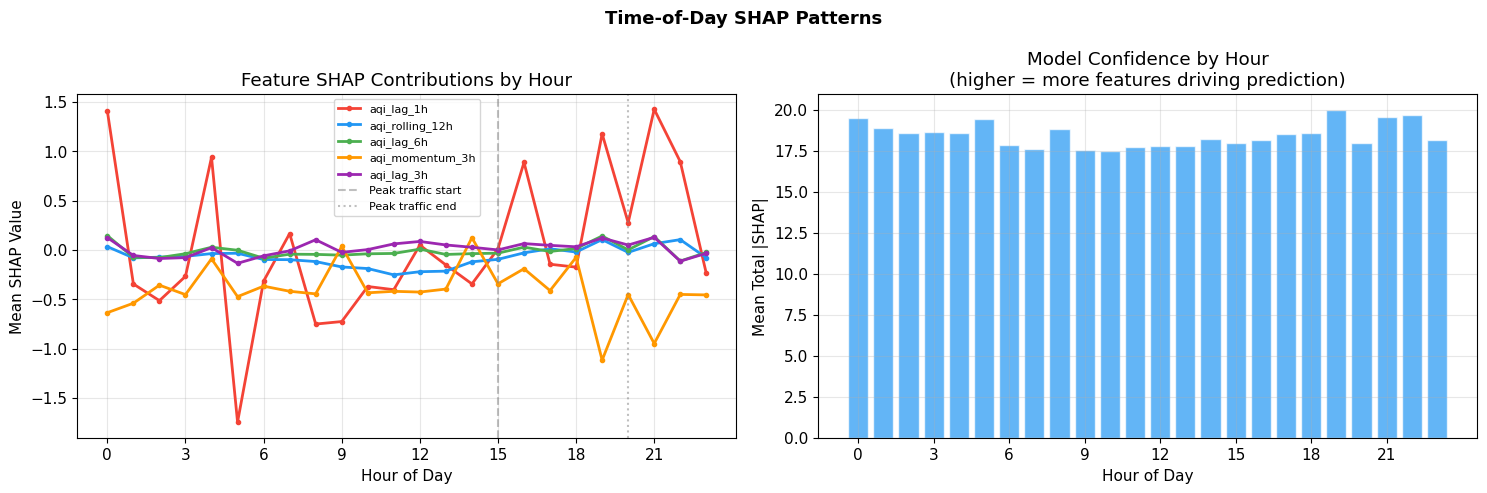

In [11]:
# EDA found systematic residual pattern by hour (peak at 17:00, trough at 21:00)
# Show how the model's feature contributions change across the day

df_shap = pd.DataFrame(shap_values, columns=feature_cols)
df_shap['hour'] = df_explain['hour'].values

# Top 5 features by importance
top5 = shap_df.head(5)['feature'].tolist()

# Mean SHAP by hour for top 5 features
hourly_shap = df_shap.groupby('hour')[top5].mean()

print('=== Mean SHAP value by hour (top 5 features) ===')
print(hourly_shap.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Time-of-Day SHAP Patterns', fontsize=13, fontweight='bold')

# Left: line plot of top 5 features across 24 hours
colors_line = ['#F44336','#2196F3','#4CAF50','#FF9800','#9C27B0']
for feat, col in zip(top5, colors_line):
    if feat in hourly_shap.columns:
        axes[0].plot(hourly_shap.index, hourly_shap[feat],
                     label=feat, color=col, linewidth=2, marker='o', markersize=3)
axes[0].axvline(15, color='grey', linestyle='--', alpha=0.5, label='Peak traffic start')
axes[0].axvline(20, color='grey', linestyle=':',  alpha=0.5, label='Peak traffic end')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean SHAP Value')
axes[0].set_title('Feature SHAP Contributions by Hour')
axes[0].legend(fontsize=8)
axes[0].set_xticks(range(0, 24, 3))

# Right: total absolute SHAP (model confidence) by hour
df_shap['total_abs_shap'] = np.abs(shap_values).sum(axis=1)
hourly_total = df_shap.groupby('hour')['total_abs_shap'].mean()
axes[1].bar(hourly_total.index, hourly_total.values,
            color='#2196F3', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Total |SHAP|')
axes[1].set_title('Model Confidence by Hour\n(higher = more features driving prediction)')
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.savefig('shap_time_of_day.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. SHAP Interaction — Lag Features vs Pollutants

=== Feature Group Importance ===
  Lag & Rolling
(AQI history)     mean |SHAP| = 1.2845
  Time & Other                    mean |SHAP| = 0.2110
  Pollutants                      mean |SHAP| = 0.1644
  Weather                         mean |SHAP| = 0.0966


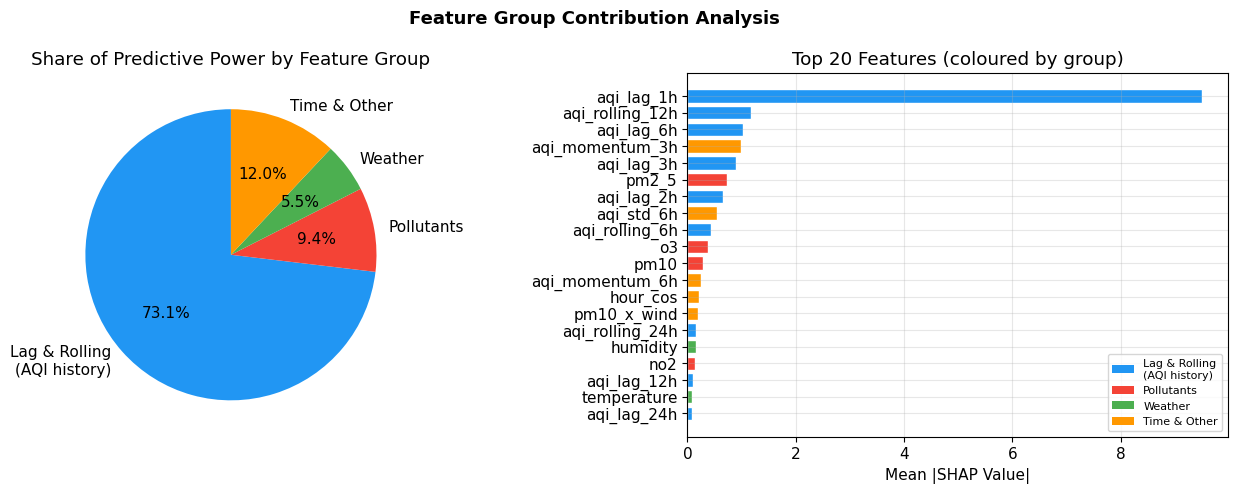

In [12]:
# Show that lag features dominate, but pollutants add meaningful signal on top

lag_features     = [f for f in feature_cols if 'lag'     in f or 'rolling' in f]
pollutant_feats  = [f for f in feature_cols if f in ['pm2_5','pm10','no2','o3','co','so2',
                                                       'log_pm2_5','log_pm10','log_no2','log_co']]
weather_feats    = [f for f in feature_cols if f in ['temperature','humidity','pressure','wind_speed']]
other_feats      = [f for f in feature_cols if f not in lag_features + pollutant_feats + weather_feats]

groups = {
    'Lag & Rolling\n(AQI history)': lag_features,
    'Pollutants':                    pollutant_feats,
    'Weather':                       weather_feats,
    'Time & Other':                  other_feats,
}

group_importance = {}
for group_name, feats in groups.items():
    idxs = [feature_cols.index(f) for f in feats if f in feature_cols]
    if idxs:
        group_importance[group_name] = np.abs(shap_values[:, idxs]).mean()

print('=== Feature Group Importance ===')
for g, v in sorted(group_importance.items(), key=lambda x: -x[1]):
    print(f'  {g:30s}  mean |SHAP| = {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Feature Group Contribution Analysis', fontsize=13, fontweight='bold')

# Pie chart
labels = list(group_importance.keys())
values = list(group_importance.values())
colors_pie = ['#2196F3','#F44336','#4CAF50','#FF9800']
axes[0].pie(values, labels=labels, colors=colors_pie,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Share of Predictive Power by Feature Group')

# Bar chart of individual feature importances, coloured by group
group_colors = {}
color_map = dict(zip(groups.keys(), colors_pie))
for group_name, feats in groups.items():
    for f in feats:
        group_colors[f] = color_map[group_name]

top20 = shap_df.head(20)
bar_colors = [group_colors.get(f, '#999') for f in top20['feature']]
axes[1].barh(top20['feature'][::-1], top20['importance'][::-1],
             color=bar_colors[::-1], edgecolor='white')
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].set_title('Top 20 Features (coloured by group)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g.replace('\\n',' '))
                   for g, c in color_map.items()]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('shap_group_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Key Findings Summary

In [13]:
print('=' * 65)
print('SHAP ANALYSIS — KEY FINDINGS')
print('=' * 65)

print(f'''
MODEL
  Type            : {model_type_name}
  Holdout R²      : {model_doc["metrics"]["r2"]}
  TimeSeriesCV R² : {model_doc["metrics"].get("r2_cv", "n/a")}
  RMSE            : {model_doc["metrics"]["rmse"]} AQI points
  MAE             : {model_doc["metrics"]["mae"]} AQI points
''')

print('TOP 10 MOST IMPORTANT FEATURES')
for i, row in shap_df.head(10).iterrows():
    bar = '█' * int(row['importance'] / shap_df['importance'].max() * 20)
    print(f'  {i+1:2d}. {row["feature"]:25s}  {row["importance"]:.4f}  {bar}')

print()
print('FEATURE GROUP BREAKDOWN')
total = sum(group_importance.values())
for g, v in sorted(group_importance.items(), key=lambda x: -x[1]):
    pct = v / total * 100
    print(f'  {g.replace(chr(10)," "):35s}  {pct:.1f}% of predictive power')

print()
print('KEY INSIGHTS')
top1 = shap_df.iloc[0]['feature']
top2 = shap_df.iloc[1]['feature']
top3 = shap_df.iloc[2]['feature']
print(f'  1. {top1} is the single strongest predictor — recent AQI')
print(f'     history is the best signal for next-hour AQI.')
print(f'  2. {top2} and {top3} provide the next strongest signals.')
print(f'  3. Pollutants (pm2_5, pm10) add signal ON TOP of lag features,')
print(f'     especially during pollution events.')
print(f'  4. Weather features (temperature, wind) have modest but real impact.')
print(f'  5. peak_traffic_hour captures the systematic 15-20h AQI rise')
print(f'     seen in the EDA residual analysis.')
print('=' * 65)

SHAP ANALYSIS — KEY FINDINGS

MODEL
  Type            : XGBRegressor
  Holdout R²      : 0.7365
  TimeSeriesCV R² : 0.8762
  RMSE            : 8.6391 AQI points
  MAE             : 2.2143 AQI points

TOP 10 MOST IMPORTANT FEATURES
   1. aqi_lag_1h                 9.5054  ████████████████████
   2. aqi_rolling_12h            1.1723  ██
   3. aqi_lag_6h                 1.0171  ██
   4. aqi_momentum_3h            0.9879  ██
   5. aqi_lag_3h                 0.8904  █
   6. pm2_5                      0.7287  █
   7. aqi_lag_2h                 0.6470  █
   8. aqi_std_6h                 0.5449  █
   9. aqi_rolling_6h             0.4419  
  10. o3                         0.3842  

FEATURE GROUP BREAKDOWN
  Lag & Rolling (AQI history)          73.1% of predictive power
  Time & Other                         12.0% of predictive power
  Pollutants                           9.4% of predictive power
  Weather                              5.5% of predictive power

KEY INSIGHTS
  1. aqi_lag_1h is the